# Aim and Objective of this Project

This is one of my early data analysis projects so the goal is pretty simple. 
I want to understand the data, clean it if needed, find some patterns and visualize them
in a way that actually makes sense.

More specifically I want to see which countries rank the highest and lowest, 
which factors are most connected to happiness and whether things like wealth or 
freedom matter more than others.

# About the dataset

This dataset is from the 2019 report and it covers 156 countries. 
Source: https://www.kaggle.com/datasets/unsdsn/world-happiness/data

# Installing the packages

In [1]:
!pip install pandas matplotlib seaborn -q

# Importing the Libraries

In [2]:
import numpy as np # for linear algebra
import pandas as pd # for Data processing 
import matplotlib.pyplot as plt # for data visualizations
import seaborn as sns # for statistical data visualization

print("Libraries loaded!")

Libraries loaded!


# Loading the Dataset

In [3]:
df = pd.read_csv('2019 dataset.csv')

# Exploratory Data Analysis

In [4]:
print("Shape:", "Columns:", df.shape[0], "Rows: ", df.shape[1])

Shape: Columns: 156 Rows:  9


In [5]:
#Displaying the first 10 rows of the dataset
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [6]:
# See all column names
print(df.columns.tolist())

['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


In [7]:
#Understanding of data type helps for computation
df.dtypes 

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

In [8]:
#Print a concise summary of a DataFrame. 
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [9]:
#Checking for null/missing values

if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    for i in df:
        if df[i].isnull().sum() > 0:
            print(f'{i} has: {df[i].isnull().sum(), "missing values."}')

No missing values found.


In [10]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
#Summary of the data set
df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


### Top 10 happiest countries

In [12]:
print("Top 10 Happiest Countries:\n")
df['Country or region'].head(10)

Top 10 Happiest Countries:



0        Finland
1        Denmark
2         Norway
3        Iceland
4    Netherlands
5    Switzerland
6         Sweden
7    New Zealand
8         Canada
9        Austria
Name: Country or region, dtype: object

### Bottom 10 least happy

In [13]:
print("Bottom 10 Least Happiest Countries:\n")
df['Country or region'].tail(10)

Bottom 10 Least Happiest Countries:



146                       Haiti
147                    Botswana
148                       Syria
149                      Malawi
150                       Yemen
151                      Rwanda
152                    Tanzania
153                 Afghanistan
154    Central African Republic
155                 South Sudan
Name: Country or region, dtype: object

# Visualization

### Distribution of Happiness Scores

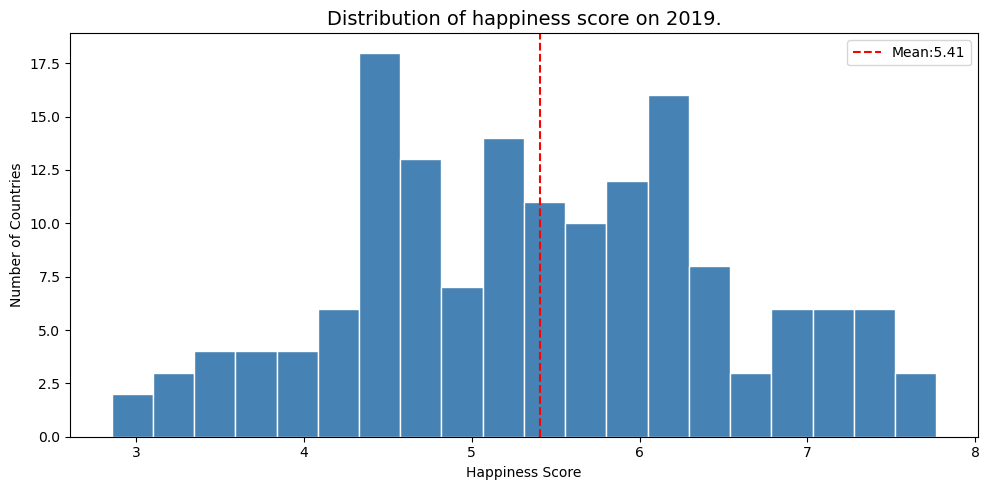

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df['Score'], bins=20, color='steelblue', edgecolor='white')

#label and title
plt.title("Distribution of happiness score on 2019.", fontsize=14)
plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")

## Adding a vertical line for the mean

plt.axvline(df['Score'].mean(), color='red', linestyle='--', label=f"Mean:{df['Score'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

The world’s happiness scores in 2019 were mostly moderate, with the average country scoring a little above 5.4.

### Top 10 AND Bottom 10 Countries

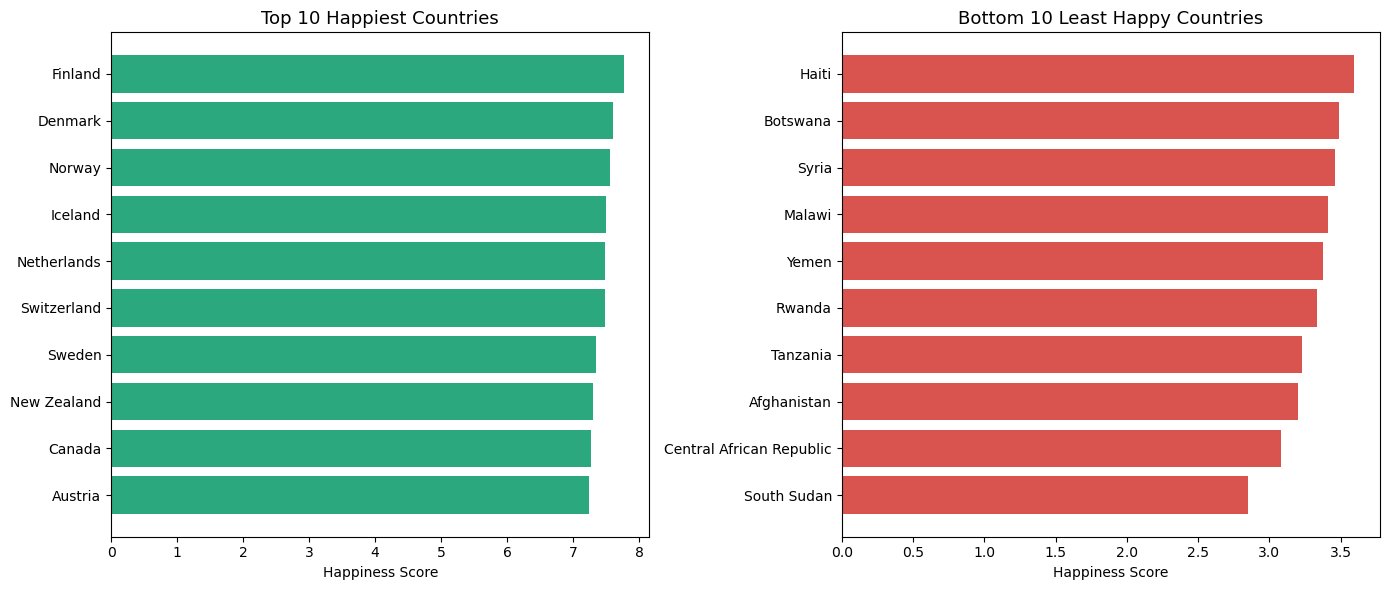

In [21]:
#TOP 10
top10 = df.head(10)
#BOTTOM 10
bottom10 = df.tail(10)

# Creating side by side plots using subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#for left chart: Top 10
axes[0].barh(top10['Country or region'], top10['Score'], color='#2ca87f')
axes[0].set_title('Top 10 Happiest Countries', fontsize=13)
axes[0].set_xlabel('Happiness Score')
axes[0].invert_yaxis()  # rank 1 appears at top

#for right chart: Bottom 10
axes[1].barh(bottom10['Country or region'], bottom10['Score'], color='#d9534f')
axes[1].set_title('Bottom 10 Least Happy Countries', fontsize=13)
axes[1].set_xlabel('Happiness Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### Correlation Heatmap

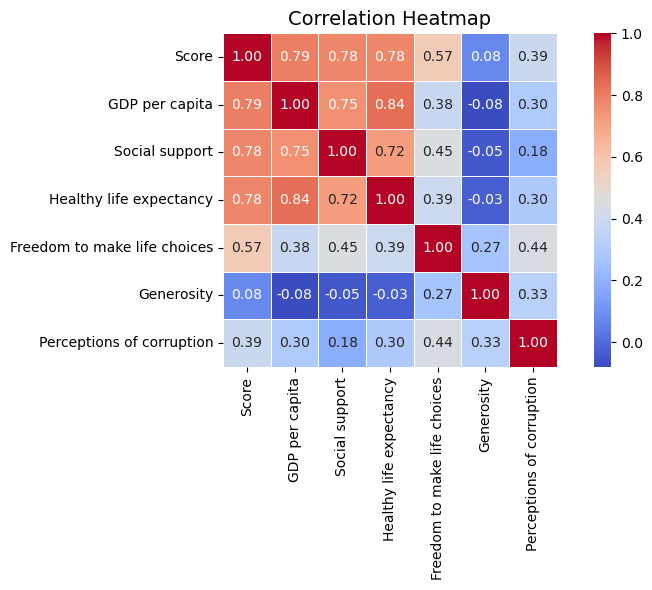

In [27]:
# Selecting only numeric columns for correlation
features = ['Score', 'GDP per capita', 'Social support',
            'Healthy life expectancy', 'Freedom to make life choices',
            'Generosity', 'Perceptions of corruption']

# Calculate correlation matrix
corr_matrix = df[features].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix,
    annot=True,       # show numbers inside each cell
    fmt='.2f',        # round to 2 decimal places
    cmap='coolwarm',  # red = high positive, blue = negative
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()



### Each Factor vs Happiness Score (Scatter Plots)

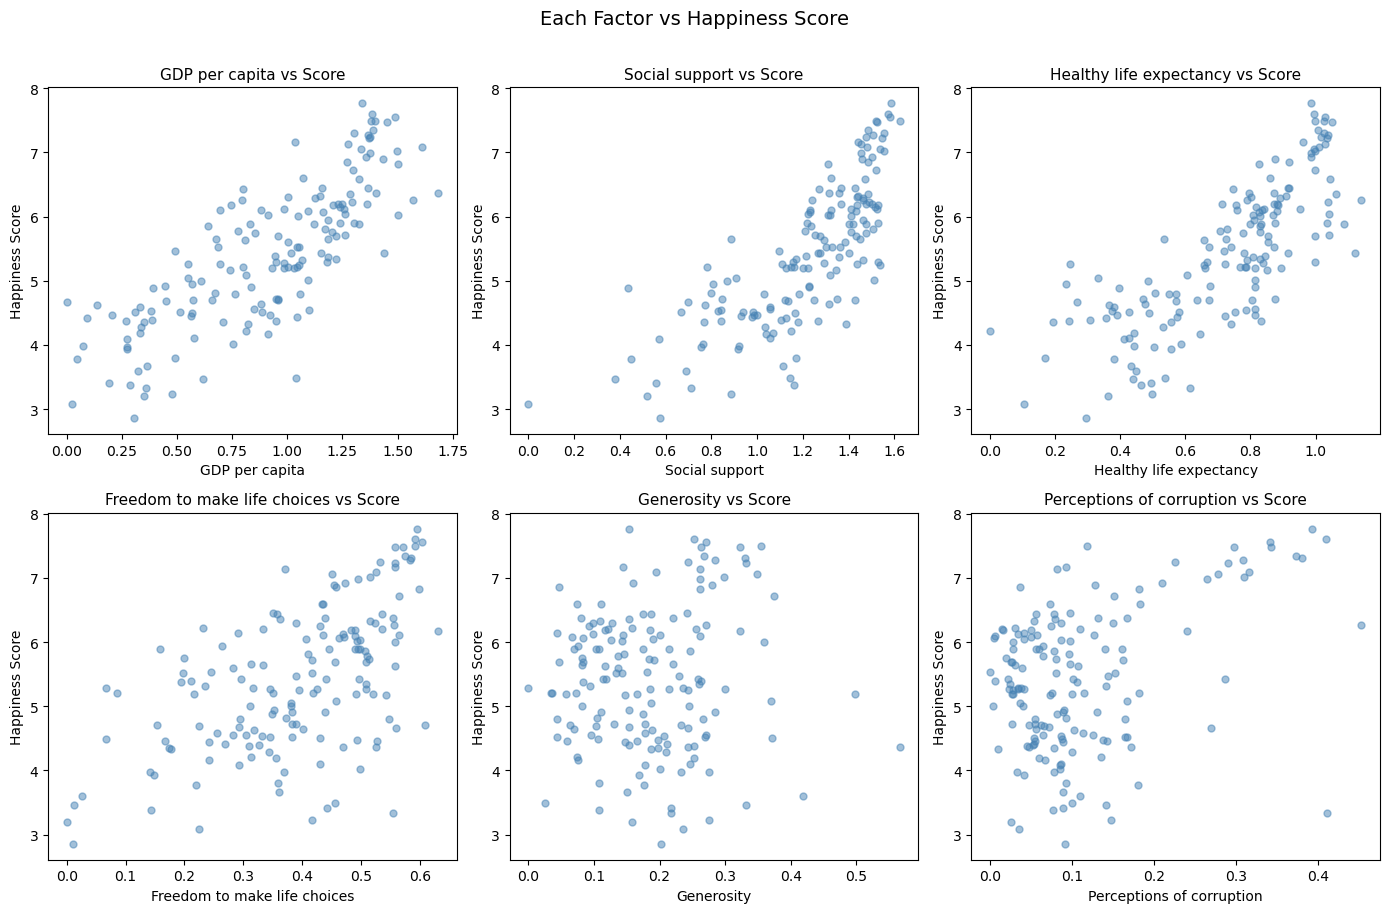

In [36]:
factors = ['GDP per capita', 'Social support', 'Healthy life expectancy',
           'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

fig, axes = plt.subplots(2,3, figsize= (14,9))
axes = axes.flatten()

for i, factor in enumerate(factors):
    axes[i].scatter(df[factor], df['Score'], alpha=0.5, color='steelblue', s=25) 
    axes[i].set_xlabel(factor, fontsize=10)
    axes[i].set_ylabel('Happiness Score', fontsize=10)
    axes[i].set_title(f'{factor} vs Score', fontsize=11)

# alpha=0.5 will make the dots semi-transparent so overlapping dots are visible
# s=25 controls the dot size

plt.suptitle('Each Factor vs Happiness Score', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Score Distribution by Groups (Box Plot)


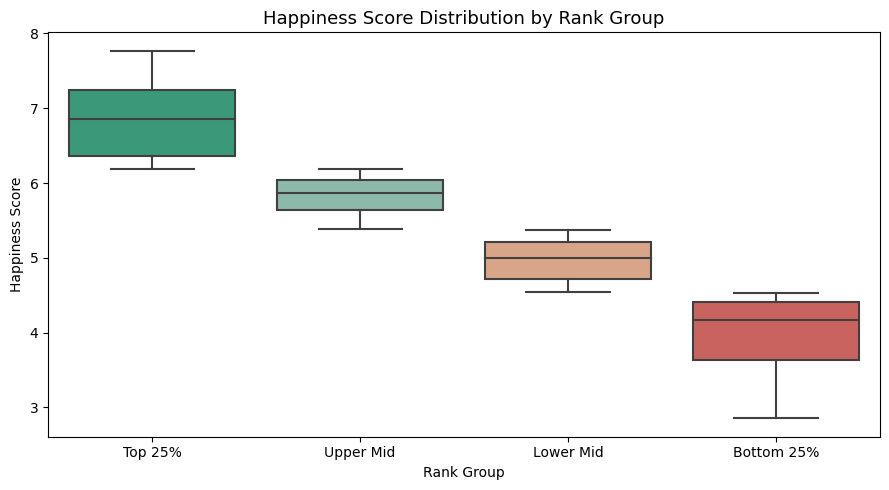

In [41]:
df['Rank Group'] = pd.qcut(df['Overall rank'], q=4,
                            labels=['Top 25%', 'Upper Mid', 'Lower Mid', 'Bottom 25%'])

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Rank Group', y='Score',
            palette=['#2ca87f', '#85c1ae', '#e6a17a', '#d9534f'])

plt.title('Happiness Score Distribution by Rank Group', fontsize=13)
plt.xlabel('Rank Group')
plt.ylabel('Happiness Score')
plt.tight_layout()
plt.show()